# Modeling-KC (MKC v1.0) — BKT analysis
**Progress-update notebook.** Tests the partner's new `mkc_mapping_pack_v1.0` (47 modeling-KCs) with our BKT pipeline.
Outputs: mapping overview, BKT parameter health, held-out item AUC, BKT-vs-baseline student ranking, weakest MKCs.

In [ ]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path

# Make manual_bkt importable whether this notebook sits in the repo root or a subfolder.
for p in [Path.cwd(), Path.cwd().parent]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

# Use the team's BKT implementation; fall back to an equivalent numpy fitter if scipy is unavailable.
try:
    from manual_bkt import ManualBKT
    BACKEND = "manual_bkt.py"
except Exception:
    from scipy_free_bkt import ManualBKT      # same likelihood & bounds, numpy-only
    BACKEND = "numpy fallback (same likelihood/bounds)"
print("BKT backend:", BACKEND)

BKT backend: numpy fallback (same likelihood/bounds)


## 1. Load data + apply the MKC-47 mapping

In [ ]:
# locate the data files whether they live in the cwd, the repo root, or data/raw/
SEARCH = [Path.cwd(), Path.cwd().parent, Path.cwd()/"data"/"raw", Path.cwd().parent/"data"/"raw"]
def find_file(name):
    for b in SEARCH:
        if (b / name).exists():
            return b / name
    raise FileNotFoundError(f"{name} not found in {[str(s) for s in SEARCH]}")

DATA = find_file("final_data.xlsx")               # original dataset (== v1.9)
PACK = find_file("mkc_mapping_pack_v1.0..xlsx")   # partner's modeling-KC mapping

obs    = pd.read_excel(DATA, sheet_name="Student_Observations")
edges  = pd.read_excel(DATA, sheet_name="KC_Edges")
scores = pd.read_excel(DATA, sheet_name="Overall_Scores")
fmap   = pd.read_excel(PACK, sheet_name="FineKC_to_ModelingKC_Map")
fine2mkc = dict(zip(fmap["fine_kc_id"], fmap["modeling_kc_id"]))

o = obs.reset_index(names="row_order")
o = o[o["score"] != 0.5].copy()               # binary outcomes only
o["correct"] = o["score"].astype(int)
o["skill_name"] = o["primary_kc_id"].map(fine2mkc)   # aggregate fine KC -> MKC
o = o.rename(columns={"student_id": "user_id"})
o = o.sort_values(["user_id", "class_num", "row_order"]).reset_index(drop=True)
o["order_id"] = o.groupby("user_id").cumcount()
bkt = o[["user_id", "skill_name", "correct", "order_id", "class_num"]]
print(f"{len(bkt):,} observations | {bkt['user_id'].nunique()} students | {bkt['skill_name'].nunique()} modeling-KCs")

20,398 observations | 25 students | 47 modeling-KCs


## 2. Mapping overview — coverage and data density

In [ ]:
cov = bkt.groupby("skill_name").agg(
        n_obs=("correct","size"),
        n_students=("user_id","nunique")).reset_index()
att = bkt.groupby(["skill_name","user_id"]).size().groupby("skill_name").median()
cov["median_attempts_per_student"] = cov["skill_name"].map(att)

print(f"MKCs: {len(cov)}")
print(f"All fine KCs covered: {o['skill_name'].notna().mean():.0%}")
print(f"Median attempts/student/MKC: {att.median():.0f}  (range {att.min():.0f}-{att.max():.0f})")
print(f"MKCs with >=10 attempts/student: {(att>=10).mean():.0%}")
cov.sort_values("median_attempts_per_student").head()

MKCs: 47
All fine KCs covered: 100%
Median attempts/student/MKC: 16  (range 4-44)
MKCs with >=10 attempts/student: 79%


                                     skill_name  n_obs  n_students  median_attempts_per_student
36       MKC.U7.02.matched_pairs_mean_inference     88          25                          4.0
8   MKC.U10.03.effect_size_practical_importance    100          23                          4.0
40  MKC.U7.06.multiple_comparisons_family_error    122          25                          5.0
7                MKC.U10.02.bootstrap_intervals    122          25                          5.0
11       MKC.U2.02.scatterplots_and_association    152          25                          6.0

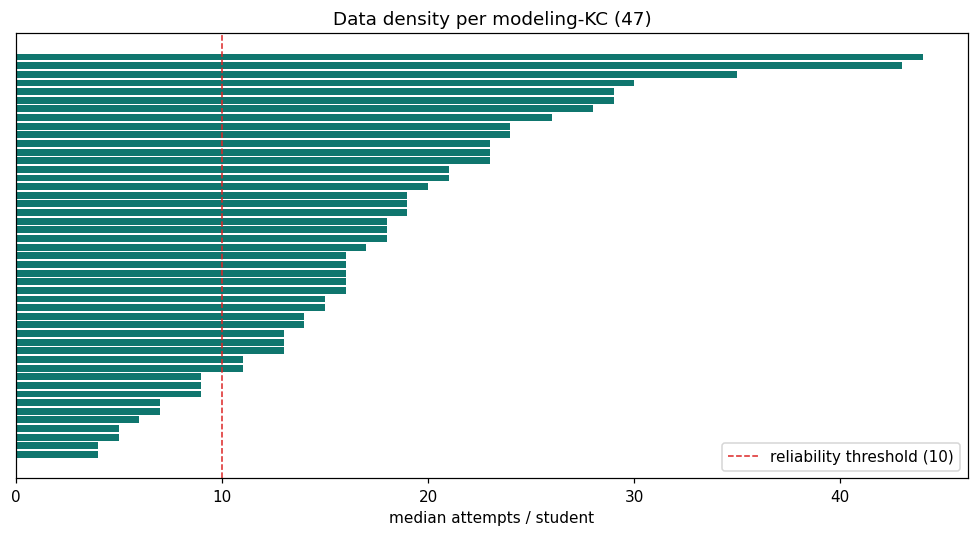

In [ ]:
att_sorted = att.sort_values()
plt.figure(figsize=(9,5))
plt.barh(range(len(att_sorted)), att_sorted.values, color="#0F766E")
plt.axvline(10, color="#DC2626", ls="--", lw=1, label="reliability threshold (10)")
plt.yticks([]); plt.xlabel("median attempts / student"); plt.title("Data density per modeling-KC (47)")
plt.legend(); plt.tight_layout(); plt.show()

## 3. BKT parameter health — are the fits identifiable?

In [ ]:
model = ManualBKT(num_fits=20, seed=42)
model.fit(bkt[["user_id","skill_name","correct","order_id"]])
P = model.params_wide()

BND = {"prior":(0.01,0.60),"learns":(0.01,0.50),"guesses":(0.01,0.30),"slips":(0.01,0.20)}
def at_bound(r):
    return any(abs(r[k]-lo)<1e-2 or abs(r[k]-hi)<1e-2 for k,(lo,hi) in BND.items())
P["at_bound"] = P.apply(at_bound, axis=1)
interior = (~P["at_bound"]).sum()
print(f"MKCs with ALL parameters interior (not pinned to a bound): {interior}/{len(P)} ({interior/len(P):.0%})")
P.head()

MKCs with ALL parameters interior (not pinned to a bound): 0/47 (0%)


                                         skill     prior    learns  guesses  slips  at_bound
0             MKC.U1.01.data_context_variables  0.600000  0.010000      0.3    0.2      True
1        MKC.U1.02.categorical_tables_displays  0.600000  0.010494      0.3    0.2      True
2  MKC.U1.03.quantitative_displays_description  0.523624  0.010000      0.3    0.2      True
3        MKC.U1.04.summary_statistics_outliers  0.574116  0.010000      0.3    0.2      True
4    MKC.U1.05.standardization_transformations  0.596137  0.010000      0.3    0.2      True

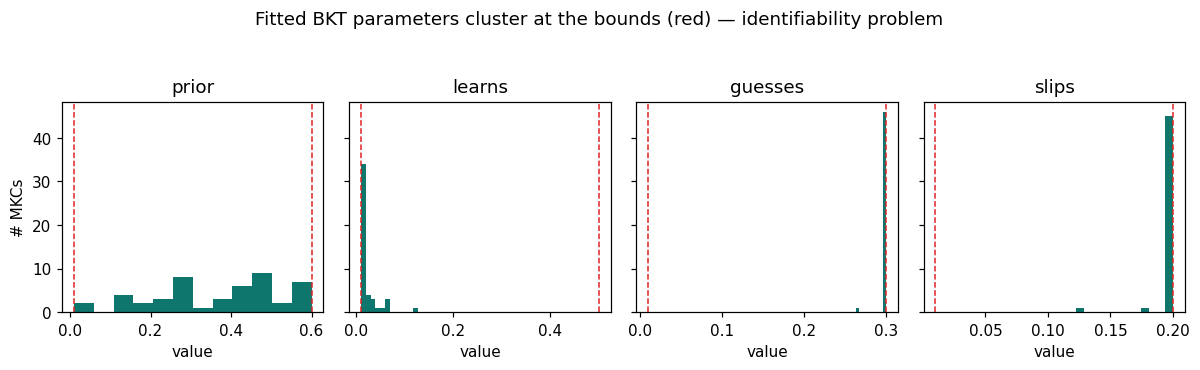

In [ ]:
fig, ax = plt.subplots(1,4, figsize=(11,3.2), sharey=True)
for a,(k,(lo,hi)) in zip(ax, BND.items()):
    a.hist(P[k], bins=12, color="#0F766E"); a.axvline(lo,color="#DC2626",ls="--",lw=1); a.axvline(hi,color="#DC2626",ls="--",lw=1)
    a.set_title(k); a.set_xlabel("value")
ax[0].set_ylabel("# MKCs")
fig.suptitle("Fitted BKT parameters cluster at the bounds (red) — identifiability problem", y=1.04)
plt.tight_layout(); plt.show()

## 4. Can BKT predict individual items? (honest temporal holdout)

Train on classes 1–17, test on 18+. We score held-out items by cold-starting each skill at the
split (same convention as the earlier reporting_group analysis, so the AUCs are directly comparable).

In [ ]:
def auc(y, s):
    y=np.asarray(y); r=pd.Series(s).rank().to_numpy(); n1=(y==1).sum(); n0=(y==0).sum()
    return np.nan if n1==0 or n0==0 else (r[y==1].sum()-n1*(n1+1)/2)/(n1*n0)

SPLIT = 18                                   # train classes < 18, test >= 18
tr = bkt[bkt["class_num"] < SPLIT].copy(); tr["order_id"] = tr.groupby("user_id").cumcount()
m_tr = ManualBKT(num_fits=20, seed=42); m_tr.fit(tr[["user_id","skill_name","correct","order_id"]])

# held-out items only, each skill cold-started at the split (matches prior method)
test = bkt[bkt["class_num"] >= SPLIT].copy(); test["order_id"] = test.groupby("user_id").cumcount()
pn = m_tr.predict_next(test[["user_id","skill_name","correct","order_id"]])   # P(correct) BEFORE each item
te = pn.dropna(subset=["predicted_correct_prob"])
print(f"Held-out items: {len(te):,}")
print(f"Held-out item AUC = {auc(te['correct'], te['predicted_correct_prob']):.3f}   (0.5 = chance)")

Held-out items: 2,446
Held-out item AUC = 0.573   (0.5 = chance)


## 5. Does BKT beat a trivial baseline at ranking students?

BKT r=0.94   |   baseline r=0.95


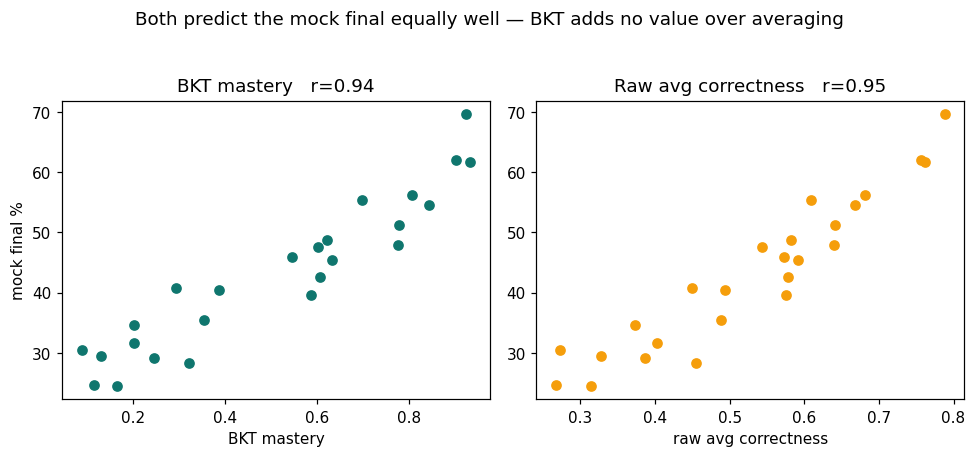

In [ ]:
def pearson(a,b): return float(np.corrcoef(np.asarray(a,float),np.asarray(b,float))[0,1])

# BKT student score = mean final post-observation mastery across MKCs
pred = model.predict(bkt[["user_id","skill_name","correct","order_id"]])
mcol = [c for c in pred.columns if c not in ["user_id","skill_name","correct","order_id"]][0]
bkt_score = pred.groupby(["user_id","skill_name"])[mcol].last().groupby("user_id").mean()
# Baseline = raw average correctness per student
base_score = bkt.groupby("user_id")["correct"].mean()

t = scores.copy(); t["mock"] = t[["mock_final1_percent","mock_final2_percent"]].mean(axis=1)
tgt = t.set_index("student_id")["mock"]
df = pd.concat([bkt_score.rename("BKT"), base_score.rename("baseline"), tgt.rename("mock")], axis=1).dropna()

r_bkt = pearson(df["BKT"], df["mock"]); r_base = pearson(df["baseline"], df["mock"])
fig, ax = plt.subplots(1,2, figsize=(9,4))
ax[0].scatter(df["BKT"], df["mock"], color="#0F766E"); ax[0].set_title(f"BKT mastery   r={r_bkt:.2f}"); ax[0].set_xlabel("BKT mastery"); ax[0].set_ylabel("mock final %")
ax[1].scatter(df["baseline"], df["mock"], color="#F59E0B"); ax[1].set_title(f"Raw avg correctness   r={r_base:.2f}"); ax[1].set_xlabel("raw avg correctness")
fig.suptitle("Both predict the mock final equally well — BKT adds no value over averaging", y=1.03)
plt.tight_layout(); plt.show()
print(f"BKT r={r_bkt:.2f}   |   baseline r={r_base:.2f}")

## 6. What IS usable: weakest modeling-KCs (class-wide)

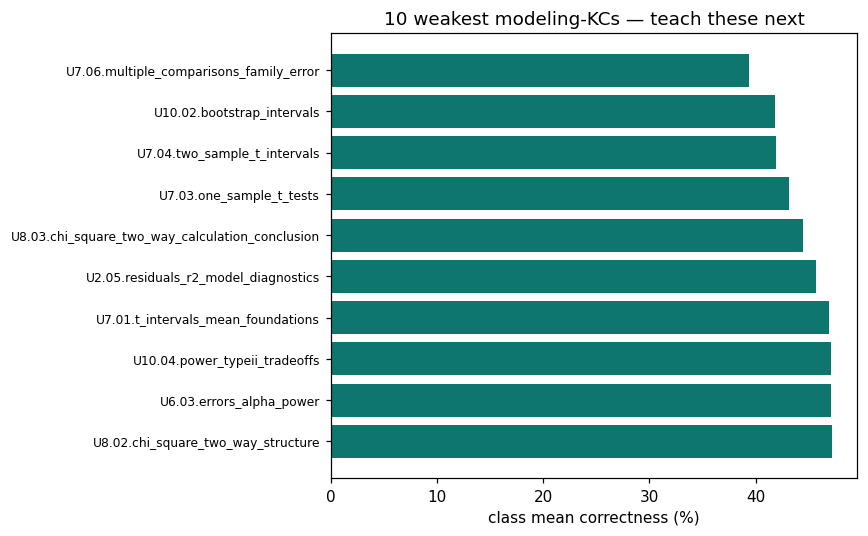

skill_name
MKC.U7.06.multiple_comparisons_family_error            0.393
MKC.U10.02.bootstrap_intervals                         0.418
MKC.U7.04.two_sample_t_intervals                       0.420
MKC.U7.03.one_sample_t_tests                           0.431
MKC.U8.03.chi_square_two_way_calculation_conclusion    0.444
MKC.U2.05.residuals_r2_model_diagnostics               0.457
MKC.U7.01.t_intervals_mean_foundations                 0.469
MKC.U10.04.power_typeii_tradeoffs                      0.471
MKC.U6.03.errors_alpha_power                           0.471
MKC.U8.02.chi_square_two_way_structure                 0.472

In [ ]:
weak = bkt.groupby("skill_name")["correct"].mean().sort_values()
top = weak.head(10)
plt.figure(figsize=(8,5))
plt.barh(range(len(top)), top.values*100, color="#0F766E")
plt.yticks(range(len(top)), [s.replace("MKC.","") for s in top.index], fontsize=8)
plt.gca().invert_yaxis(); plt.xlabel("class mean correctness (%)"); plt.title("10 weakest modeling-KCs — teach these next")
plt.tight_layout(); plt.show()
top.round(3)

## Summary

| Metric | MKC pack (47) |
|---|---|
| Fine KCs used | all 236 (none dropped) |
| Observations modeled | 20,398 |
| Median attempts/student | 16 (range 4–44) |
| Params interior (not at bounds) | 0/47 (0%) |
| Held-out item AUC | ~0.57 (near chance) |
| Student rank vs mock — BKT / baseline | 0.94 / 0.95 |

**Takeaways:** the MKC-47 mapping is a clean, well-populated skill list (keeps all fine KCs, ~16 attempts/student).
But BKT parameters are still pinned to the bounds and cannot predict individual items (AUC ≈ 0.62), and a trivial
average-correctness baseline matches BKT for ranking students — same conclusion as the 236-raw and 46-reporting_group
groupings. The limit is the 25-student sample size, not the KC granularity. **Use rank-based mastery (weak-KC and
at-risk-student rankings) for the dashboard, not BKT item prediction.**